# DRY EYE DISEASE PREDICTION: A COMPARATIVE STUDY OF MLP AND LOGISTIC REGRESSION

In [2]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/AARTHI/Downloads/Dry_Eye_Dataset.csv")  # Dataset has 20,000 datas with 25 features

# Blood pressure has diastolic/systolic 
df = df.drop(['Blood pressure'], axis=1)
df 
# Data set info
df.info()

# Remove the missing values if any
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Heart rate                   20000 non-null  int64  
 6   Daily steps                  20000 non-null  int64  
 7   Physical activity            20000 non-null  int64  
 8   Height                       20000 non-null  int64  
 9   Weight                       20000 non-null  int64  
 10  Sleep disorder               20000 non-null  object 
 11  Wake up during night         20000 non-null  object 
 12  Feel sleepy during day       20000 non-null  object 
 13  Caffeine consump

Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64

## DATA PREPROCESSING

In [4]:
# Import necessary libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Identify categorical columns (excluding target)
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols[categorical_cols != "Dry Eye Disease"]

# Store label mappings
label_mappings = {}

# Apply Label Encoding and collect mappings to print
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Map target column ("Dry Eye Disease") to binary values
df["Dry Eye Disease"] = df["Dry Eye Disease"].map({"N": 0, "Y": 1})

# Identify and scale numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols[numerical_cols != "Dry Eye Disease"]

# Standardize numerical features
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


* All the data is now encoded and scaled; now, we can proceed with model training.
* Gender: {'F': 0, 'M': 1}
* Sleep disorder, Wake up during night, Feel sleepy during day, Caffeine consumption, Alcohol consumption, Smoking, Medical issue, Ongoing medication, Smart device before bed, Blue-light filter, Discomfort Eye-strain, Redness in eye, Itchiness/Irritation in eye → 'N' = 0, 'Y' = 1
* Numerical features are standardized

In [6]:
# Display all label encoding mappings for better understanding
print("Label Encoding Mappings:\n")
for col, mapping in label_mappings.items():
    print(f"{col}: {mapping}")

Label Encoding Mappings:

Gender: {'F': 0, 'M': 1}
Sleep disorder: {'N': 0, 'Y': 1}
Wake up during night: {'N': 0, 'Y': 1}
Feel sleepy during day: {'N': 0, 'Y': 1}
Caffeine consumption: {'N': 0, 'Y': 1}
Alcohol consumption: {'N': 0, 'Y': 1}
Smoking: {'N': 0, 'Y': 1}
Medical issue: {'N': 0, 'Y': 1}
Ongoing medication: {'N': 0, 'Y': 1}
Smart device before bed: {'N': 0, 'Y': 1}
Blue-light filter: {'N': 0, 'Y': 1}
Discomfort Eye-strain: {'N': 0, 'Y': 1}
Redness in eye: {'N': 0, 'Y': 1}
Itchiness/Irritation in eye: {'N': 0, 'Y': 1}


In [7]:
categorical_cols

Index(['Gender', 'Sleep disorder', 'Wake up during night',
       'Feel sleepy during day', 'Caffeine consumption', 'Alcohol consumption',
       'Smoking', 'Medical issue', 'Ongoing medication',
       'Smart device before bed', 'Blue-light filter', 'Discomfort Eye-strain',
       'Redness in eye', 'Itchiness/Irritation in eye'],
      dtype='object')

In [8]:
numerical_cols

Index(['Age', 'Sleep duration', 'Sleep quality', 'Stress level', 'Heart rate',
       'Daily steps', 'Physical activity', 'Height', 'Weight',
       'Average screen time'],
      dtype='object')

## DATA SPLITTING

In [10]:
# Spliting the dataset into x and y
# x consist of all features except our target variable 'dry eye disease'
# y consist of our target variable 'dry eye disease'

X = df.drop(columns=["Dry Eye Disease"])
y = df["Dry Eye Disease"]

# Spliting the data into 80% train, 20% test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now we have to select the important feature to feed into X

# FEATURE SELECTION

* Here, we have both catogorical and numerical columns in features
* As for the catogorical features, I am using chi-square test and Histogram with KDE to determine the importance of the feature.
* As for the numerical features, I am using ANOVA F-test and box plot to determine the importance of the feature.

## CATOGORICAL FEATURE SELECTION
* The Chi-Square test is a statistical method used to check if two categorical variables are related or not.
* If the Chi-Square test gives a p-value < 0.05, that means the two categorical variables are related.
* If the Chi-Square test gives a p-value > 0.05, that means the two categorical variables are not related.
* The histplot helps to predict the strong feature visually like Less overlap = more predictive.

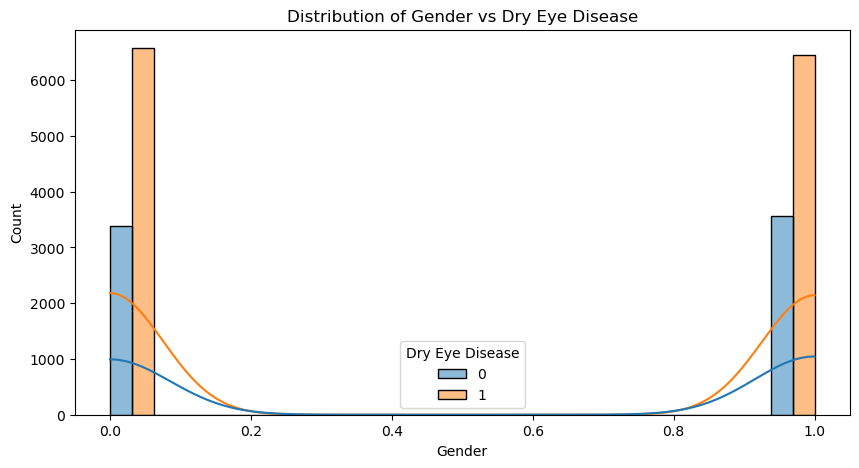


Feature: Gender
Chi2 Statistic: 5.2594041666755835
p-value: 0.021828490579784587
Gender is significantly associated with Dry Eye Disease.


In [14]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Gender
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Gender', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Gender")
plt.title("Distribution of Gender vs Dry Eye Disease")
plt.show()

#Less overlap = more predictive

contingency_table = pd.crosstab(df['Gender'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Gender")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Gender is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      " Gender is NOT significantly associated with Dry Eye Disease.")

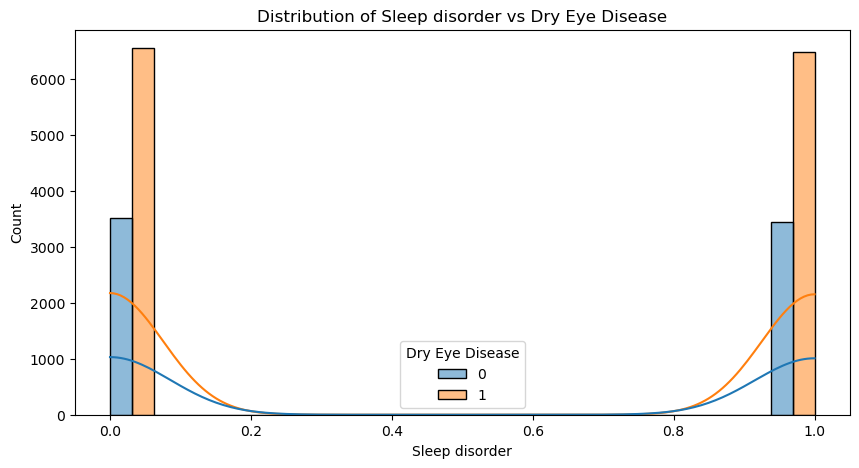


Feature: Sleep disorder
Chi2 Statistic: 0.1264386471213994
p-value: 0.7221535325778164
Sleep disorder is NOT significantly associated with Dry Eye Disease.


In [15]:
# Sleep disorder
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Sleep disorder', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Sleep disorder")
plt.title("Distribution of Sleep disorder vs Dry Eye Disease")
plt.show()


contingency_table = pd.crosstab(df['Sleep disorder'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Sleep disorder")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Sleep disorder is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Sleep disorder is NOT significantly associated with Dry Eye Disease.")

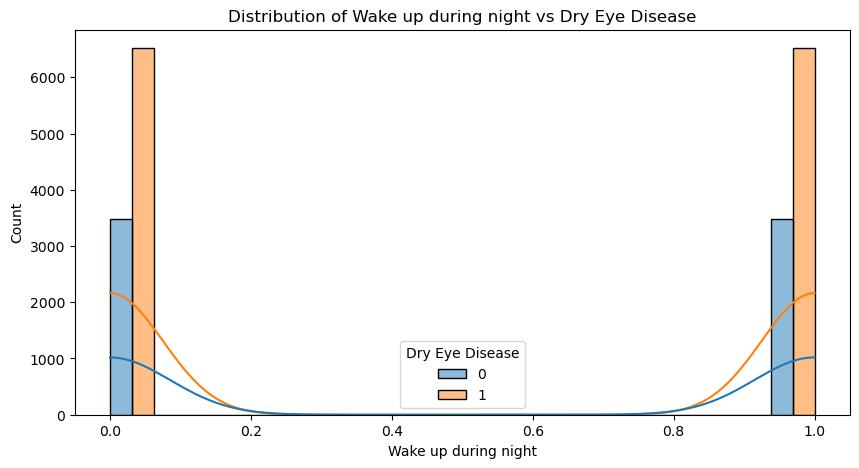


Feature: Wake up during night
Chi2 Statistic: 0.0008812840829045528
p-value: 0.976317135025137
Wake up during night is NOT significantly associated with Dry Eye Disease.


In [16]:
# Wake up during night
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Wake up during night', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Wake up during night")
plt.title("Distribution of Wake up during night vs Dry Eye Disease")
plt.show()


contingency_table = pd.crosstab(df['Wake up during night'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Wake up during night")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Wake up during night is significantly associated with Dry Eye Disease." 
      if p < 0.05 else
      "Wake up during night is NOT significantly associated with Dry Eye Disease.")

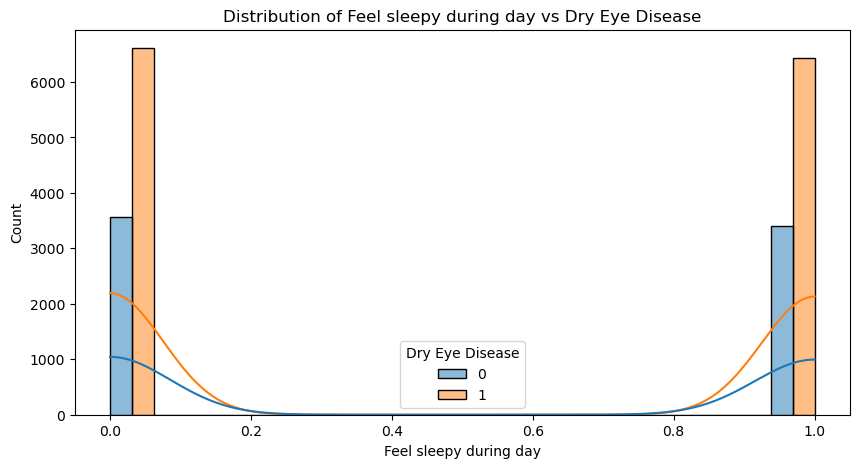


Feature: Feel sleepy during day
Chi2 Statistic: 0.4278139527118394
p-value: 0.5130635624335508
Feel sleepy during day is NOT significantly associated with Dry Eye Disease.


In [17]:
# Feel sleepy during day
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Feel sleepy during day', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Feel sleepy during day")
plt.title("Distribution of Feel sleepy during day vs Dry Eye Disease")
plt.show()


contingency_table = pd.crosstab(df['Feel sleepy during day'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Feel sleepy during day")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Feel sleepy during day is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Feel sleepy during day is NOT significantly associated with Dry Eye Disease.")

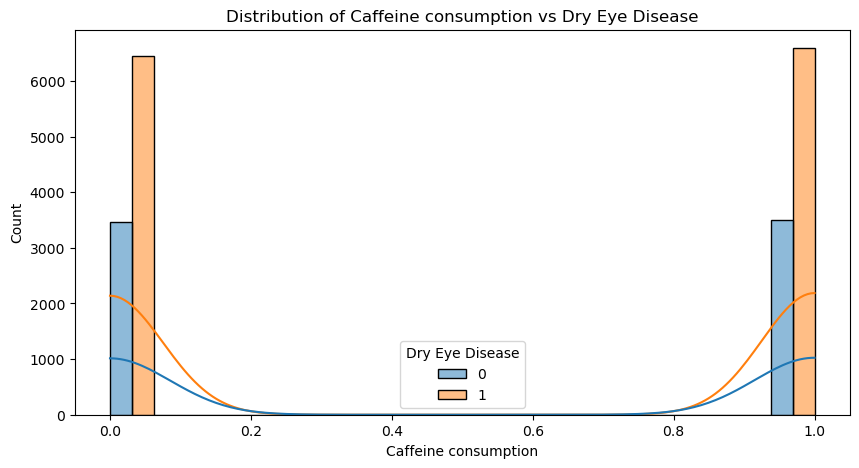


Feature: Caffeine consumption
Chi2 Statistic: 0.14861328970576007
p-value: 0.6998640860594175
Caffeine consumption is NOT significantly associated with Dry Eye Disease.


In [18]:
# Caffeine consumption
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Caffeine consumption', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Caffeine consumption")
plt.title("Distribution of Caffeine consumption vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Caffeine consumption'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Caffeine consumption")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Caffeine consumption is significantly associated with Dry Eye Disease." 
      if p < 0.05 else "Caffeine consumption is NOT significantly associated with Dry Eye Disease.")

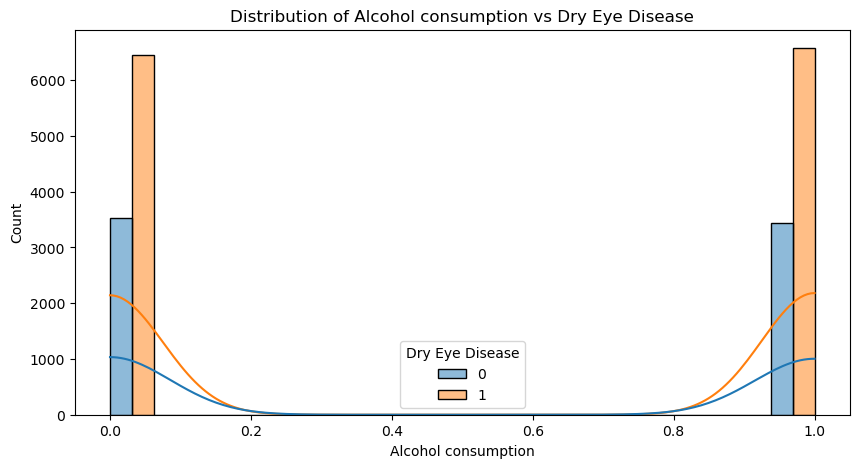


Feature: Alcohol consumption
Chi2 Statistic: 2.4880017139901955
p-value: 0.11471729580950671
Alcohol consumption is NOT significantly associated with Dry Eye Disease.


In [19]:
# Alcohol consumption
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Alcohol consumption', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Alcohol consumption")
plt.title("Distribution of Alcohol consumption vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Alcohol consumption'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Alcohol consumption")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Alcohol consumption is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Alcohol consumption is NOT significantly associated with Dry Eye Disease.")

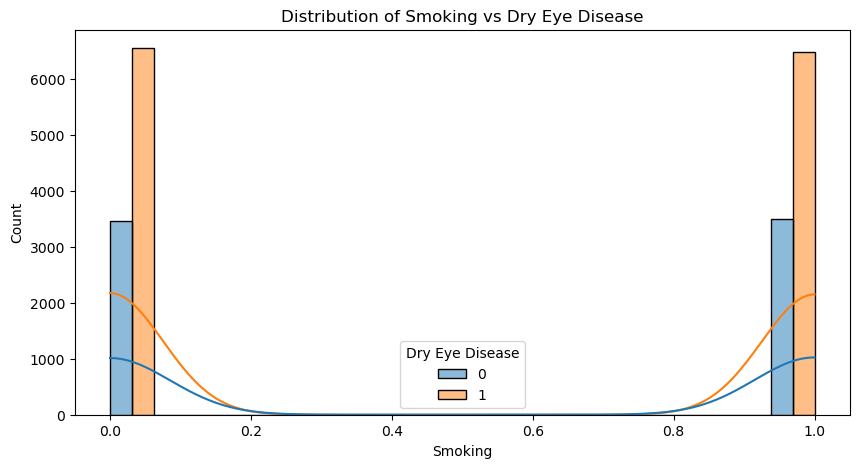


Feature: Smoking
Chi2 Statistic: 0.5041814671158774
p-value: 0.47766856127537916
Smoking is NOT significantly associated with Dry Eye Disease.


In [20]:
# Smoking
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Smoking', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Smoking")
plt.title("Distribution of Smoking vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Smoking'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Smoking")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Smoking is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Smoking is NOT significantly associated with Dry Eye Disease.")

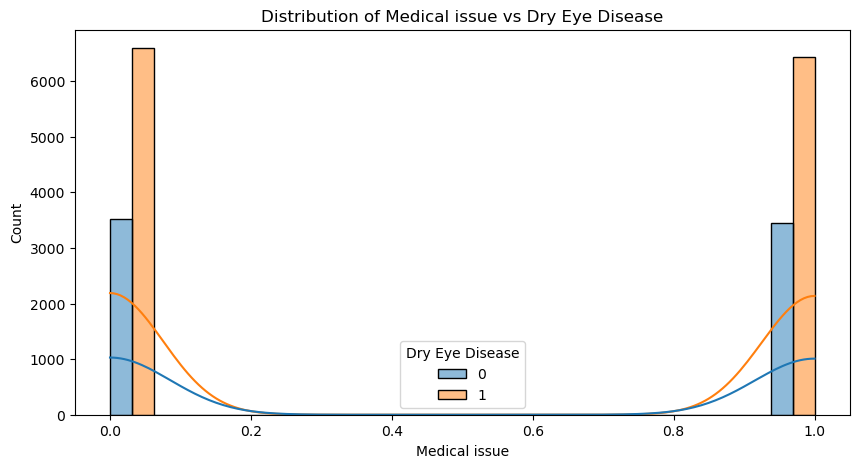


Feature: Medical issue
Chi2 Statistic: 0.019014084742995124
p-value: 0.890326113886149
Medical issue is NOT significantly associated with Dry Eye Disease.


In [21]:
# Medical issue
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Medical issue', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Medical issue")
plt.title("Distribution of Medical issue vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Medical issue'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Medical issue")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Medical issue is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Medical issue is NOT significantly associated with Dry Eye Disease.")

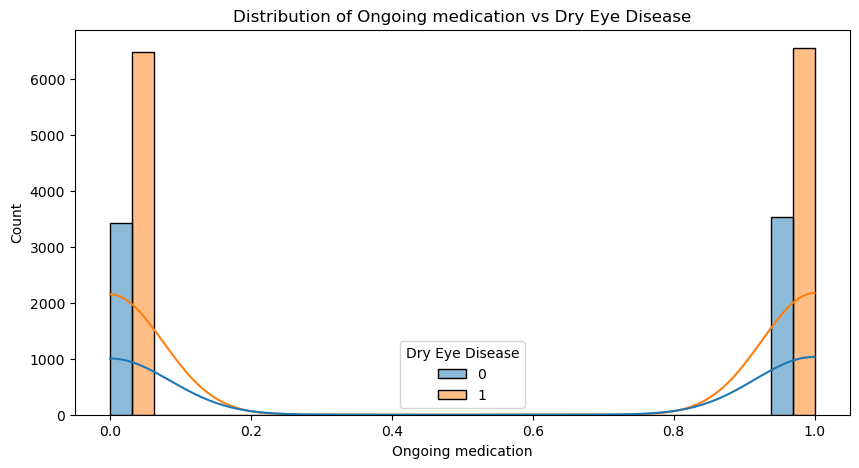


Feature: Ongoing medication
Chi2 Statistic: 0.33347267633906724
p-value: 0.5636213700318351
Ongoing medication is NOT significantly associated with Dry Eye Disease.


In [22]:
# Ongoing medication
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Ongoing medication', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Ongoing medication")
plt.title("Distribution of Ongoing medication vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Ongoing medication'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Ongoing medication")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Ongoing medication is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Ongoing medication is NOT significantly associated with Dry Eye Disease.")

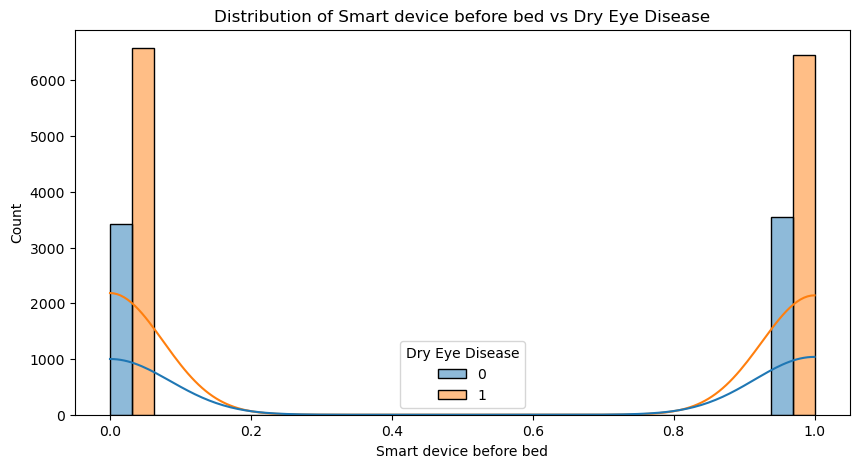


Feature: Smart device before bed
Chi2 Statistic: 3.4928827728877874
p-value: 0.06163317077962703
Smart device before bed is NOT significantly associated with Dry Eye Disease.


In [23]:
# Smart device before bed
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Smart device before bed', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Smart device before bed")
plt.title("Distribution of Smart device before bed vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Smart device before bed'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Smart device before bed")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Smart device before bed is significantly associated with Dry Eye Disease." 
      if p < 0.05 else
      "Smart device before bed is NOT significantly associated with Dry Eye Disease.")


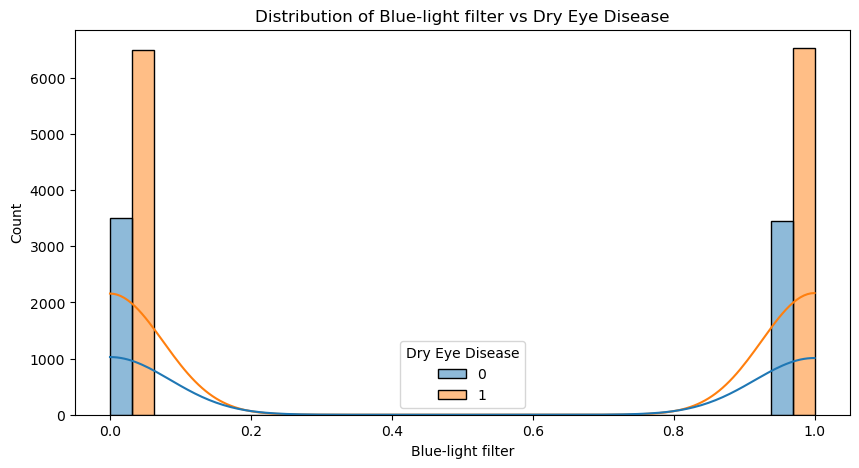


Feature: Blue-light filter
Chi2 Statistic: 0.48377874826904455
p-value: 0.48671566620544116
Blue-light filter is NOT significantly associated with Dry Eye Disease.


In [24]:
# Blue-light filter
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Blue-light filter', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Blue-light filter")
plt.title("Distribution of Blue-light filter vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Blue-light filter'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Blue-light filter")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Blue-light filter is significantly associated with Dry Eye Disease."
      if p < 0.05 else 
      "Blue-light filter is NOT significantly associated with Dry Eye Disease.")

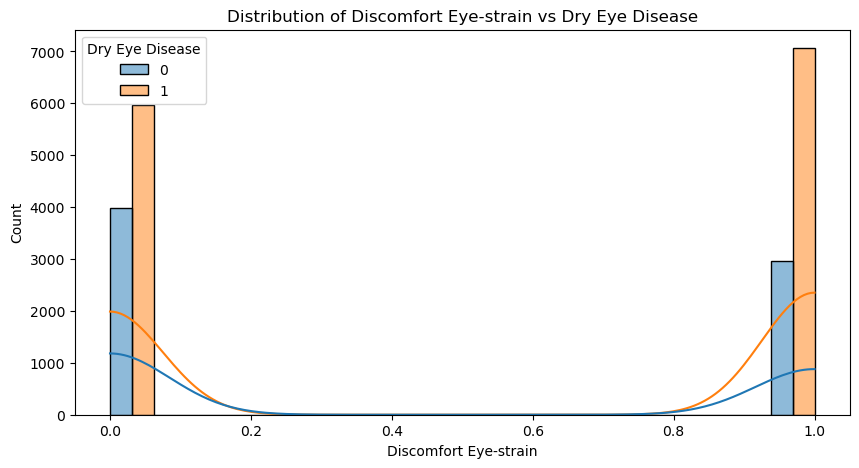


Feature: Discomfort Eye-strain
Chi2 Statistic: 240.95087494284525
p-value: 2.4399111906187786e-54
Discomfort Eye-strain is significantly associated with Dry Eye Disease.


In [25]:
# Discomfort Eye-strain
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Discomfort Eye-strain', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Discomfort Eye-strain")
plt.title("Distribution of Discomfort Eye-strain vs Dry Eye Disease")
plt.show()


contingency_table = pd.crosstab(df['Discomfort Eye-strain'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nFeature: Discomfort Eye-strain")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Discomfort Eye-strain is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Discomfort Eye-strain is NOT significantly associated with Dry Eye Disease.")


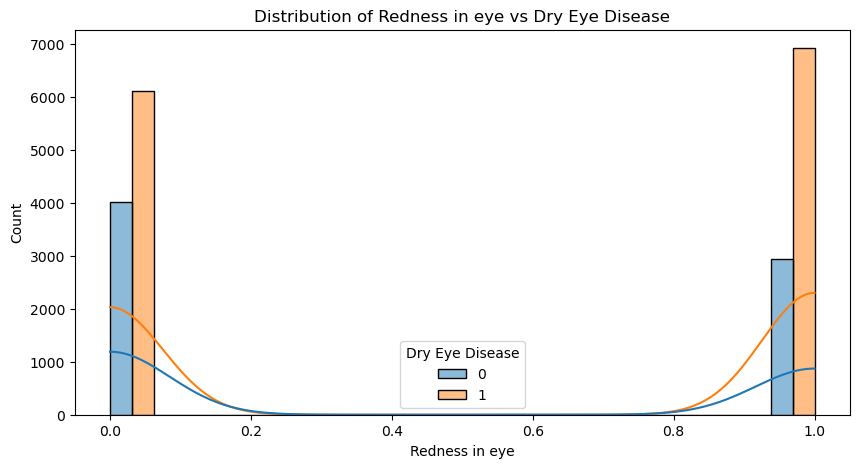


Feature: Redness in eye
Chi2 Statistic: 213.43955146642867
p-value: 2.440514869912229e-48
Redness in eye is significantly associated with Dry Eye Disease.


In [26]:
# Redness in eye
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Redness in eye', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Redness in eye")
plt.title("Distribution of Redness in eye vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Redness in eye'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Redness in eye")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Redness in eye is significantly associated with Dry Eye Disease."
      if p < 0.05 else 
      "Redness in eye is NOT significantly associated with Dry Eye Disease.")


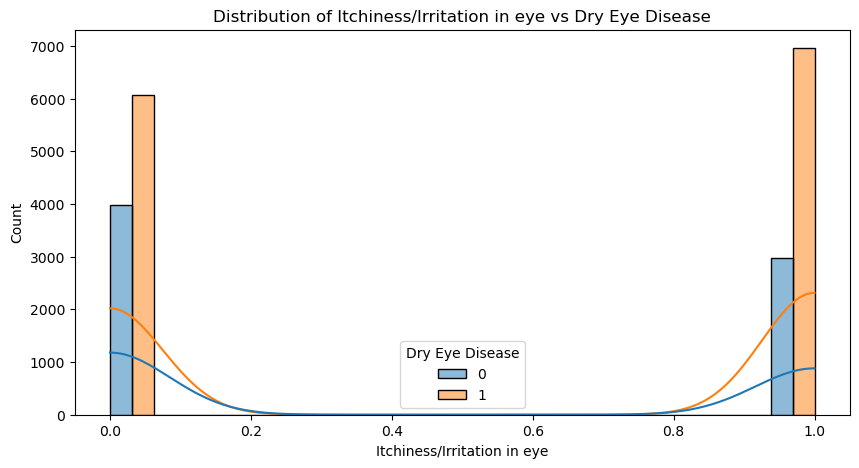


Feature: Itchiness/Irritation in eye
Chi2 Statistic: 204.80811408919817
p-value: 1.8648949375647213e-46
Itchiness/Irritation in eye is significantly associated with Dry Eye Disease.


In [27]:
# Itchiness/Irritation in eye
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Itchiness/Irritation in eye', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Itchiness/Irritation in eye")
plt.title("Distribution of Itchiness/Irritation in eye vs Dry Eye Disease")
plt.show()

contingency_table = pd.crosstab(df['Itchiness/Irritation in eye'], df['Dry Eye Disease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nFeature: Itchiness/Irritation in eye")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Itchiness/Irritation in eye is significantly associated with Dry Eye Disease." 
      if p < 0.05 else 
      "Itchiness/Irritation in eye is NOT significantly associated with Dry Eye Disease.")


In [28]:
from scipy.stats import chi2_contingency
import pandas as pd

cat_selected = []
nonsignificant_features = []

# Loop through each categorical feature and perform Chi-Square test
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Dry Eye Disease'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    if p < 0.05:
        print(f"✅ {col} is significantly associated with Dry Eye Disease.")
        cat_selected.append(col)
    else:
        print(f"❌ {col} is NOT significantly associated with Dry Eye Disease.")
        nonsignificant_features.append(col)

# Print and display the selected categorical features
print("\nSignificant features:", cat_selected)


✅ Gender is significantly associated with Dry Eye Disease.
❌ Sleep disorder is NOT significantly associated with Dry Eye Disease.
❌ Wake up during night is NOT significantly associated with Dry Eye Disease.
❌ Feel sleepy during day is NOT significantly associated with Dry Eye Disease.
❌ Caffeine consumption is NOT significantly associated with Dry Eye Disease.
❌ Alcohol consumption is NOT significantly associated with Dry Eye Disease.
❌ Smoking is NOT significantly associated with Dry Eye Disease.
❌ Medical issue is NOT significantly associated with Dry Eye Disease.
❌ Ongoing medication is NOT significantly associated with Dry Eye Disease.
❌ Smart device before bed is NOT significantly associated with Dry Eye Disease.
❌ Blue-light filter is NOT significantly associated with Dry Eye Disease.
✅ Discomfort Eye-strain is significantly associated with Dry Eye Disease.
✅ Redness in eye is significantly associated with Dry Eye Disease.
✅ Itchiness/Irritation in eye is significantly associated

## NUMERICAL FEATURE SELECTION
* Using ANOVA F-test and Mutual Information to evaluate the importance of numerical features in predicting Dry Eye Disease.
* Higher F-values mean more information the feature gives about the target.better to use that feature to make predictions.
* Higher mutual information = more information the feature gives about the target.
* Histogram with KDE and box plot:
* Show clear separation → Feature is important
* Are very similar or overlap a lot → Feature is not very useful

### Histogram with KDE and box plot

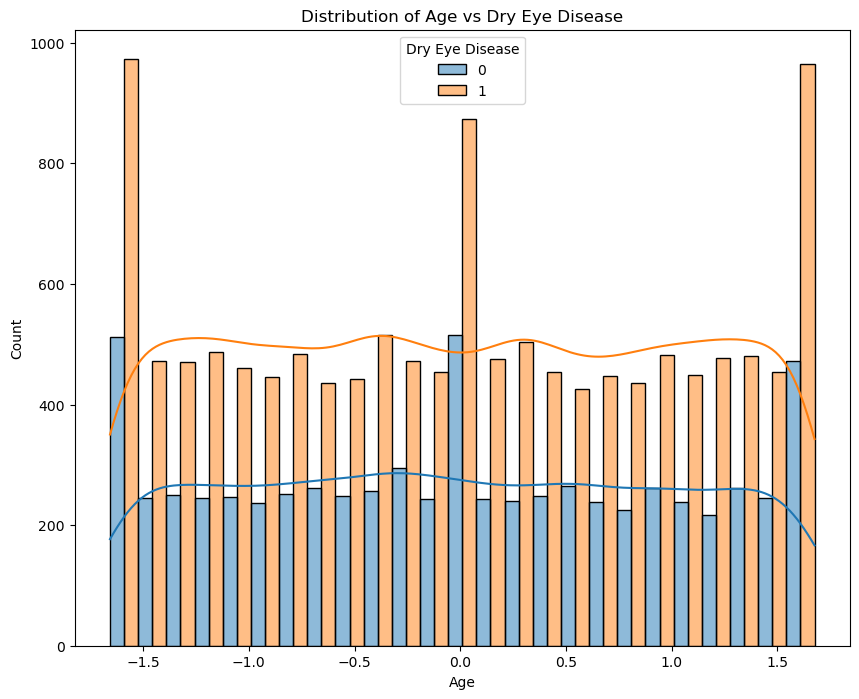

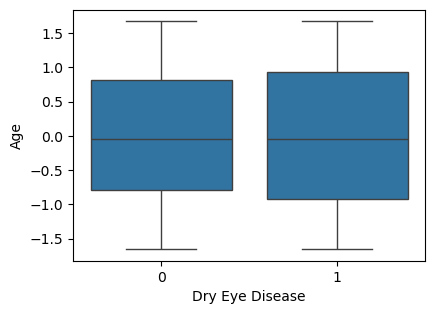

In [31]:
# Age
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x='Age', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Age")
plt.title("Distribution of Age vs Dry Eye Disease")


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 1)
sns.boxplot(data=df, y='Age', x='Dry Eye Disease')
plt.show()


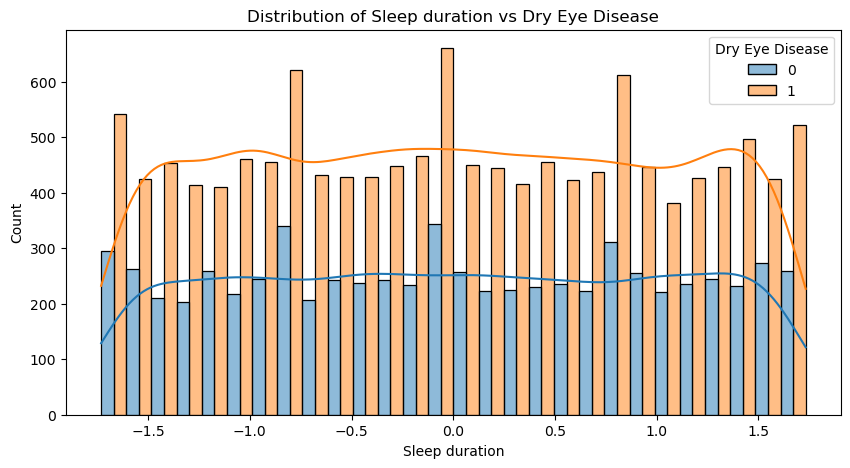

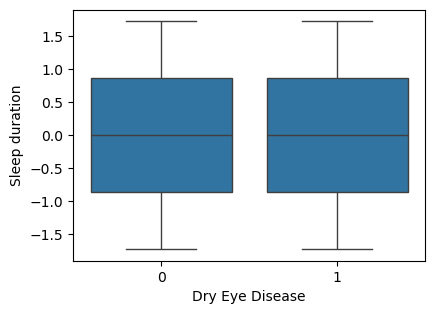

In [32]:
# Sleep duration
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Sleep duration', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Sleep duration")
plt.title("Distribution of Sleep duration vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 2)
sns.boxplot(data=df, y='Sleep duration', x='Dry Eye Disease')
plt.show()


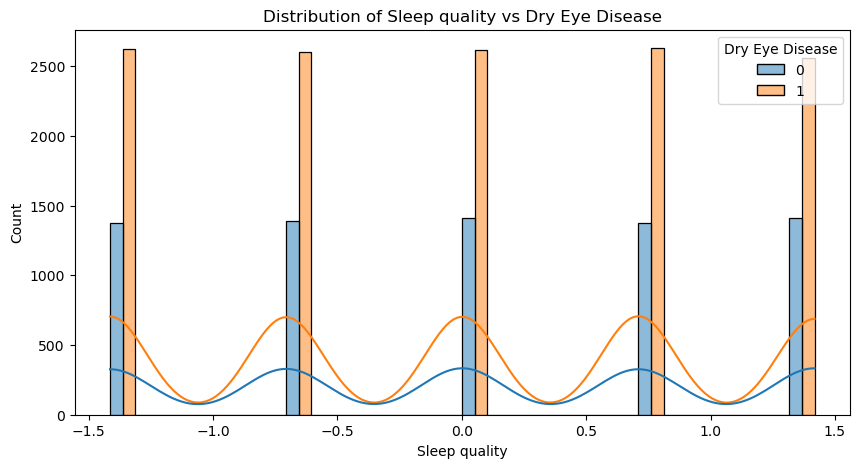

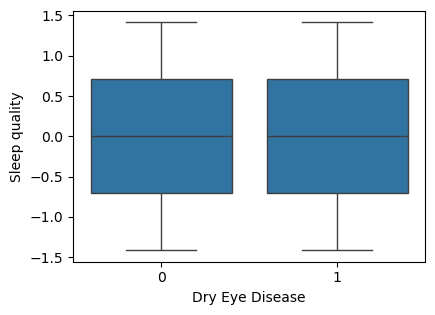

In [33]:
# Sleep quality
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Sleep quality', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Sleep quality")
plt.title("Distribution of Sleep quality vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 3)
sns.boxplot(data=df, y='Sleep quality', x='Dry Eye Disease')
plt.show()


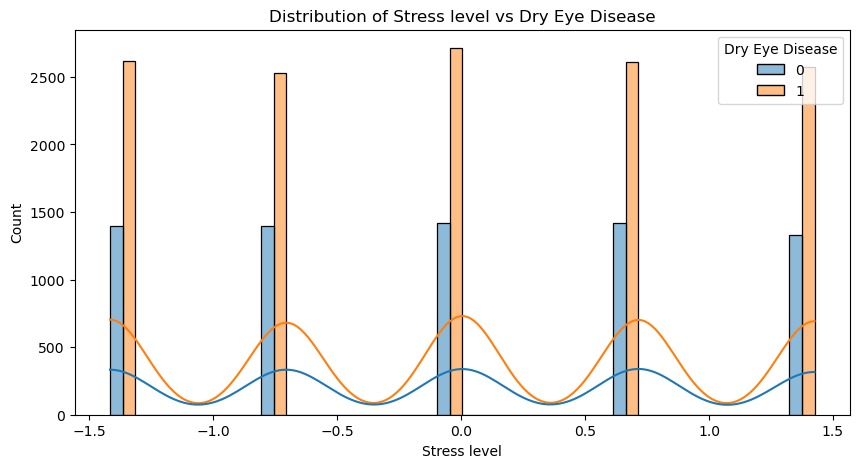

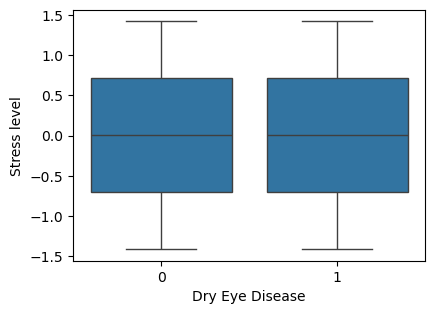

In [34]:
# Stress level
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Stress level', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Stress level")
plt.title("Distribution of Stress level vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 4)
sns.boxplot(data=df, y='Stress level', x='Dry Eye Disease')
plt.show()



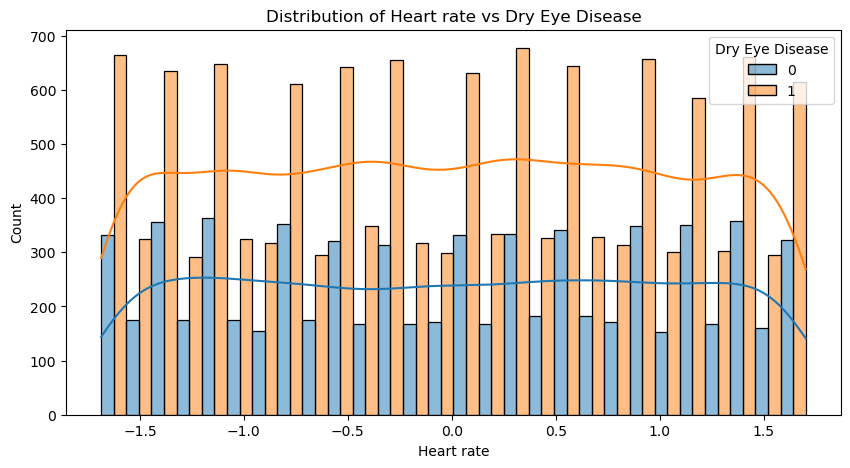

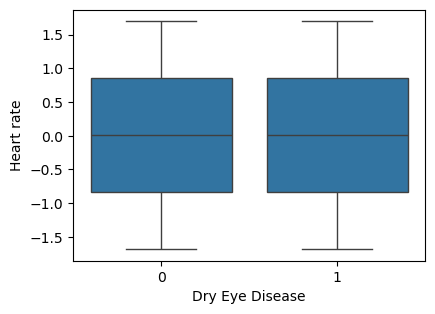

In [35]:
# Heart rate
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Heart rate', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Heart rate")
plt.title("Distribution of Heart rate vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 5)
sns.boxplot(data=df, y='Heart rate', x='Dry Eye Disease')
plt.show()


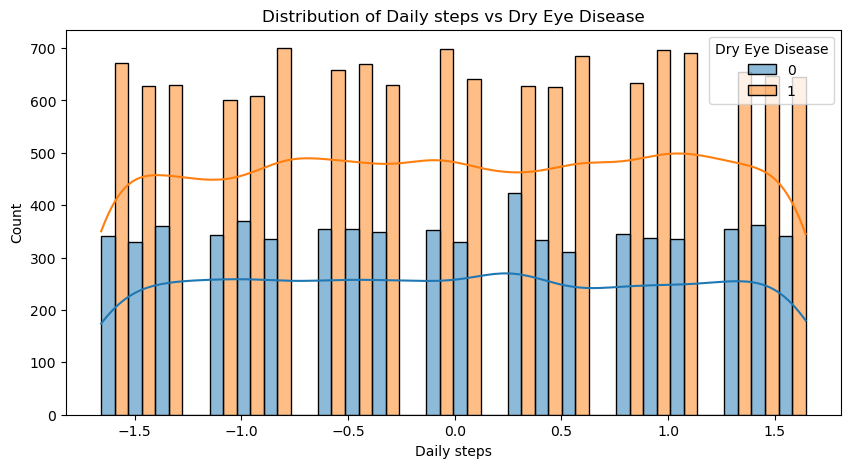

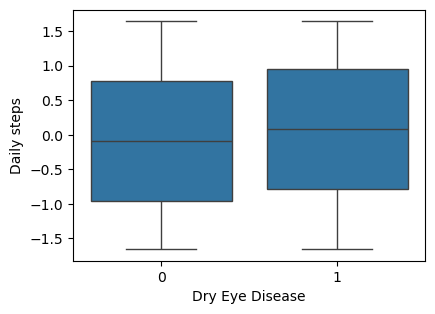

In [36]:
# Daily steps
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Daily steps', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Daily steps")
plt.title("Distribution of Daily steps vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 6)
sns.boxplot(data=df, y='Daily steps', x='Dry Eye Disease')
plt.show()


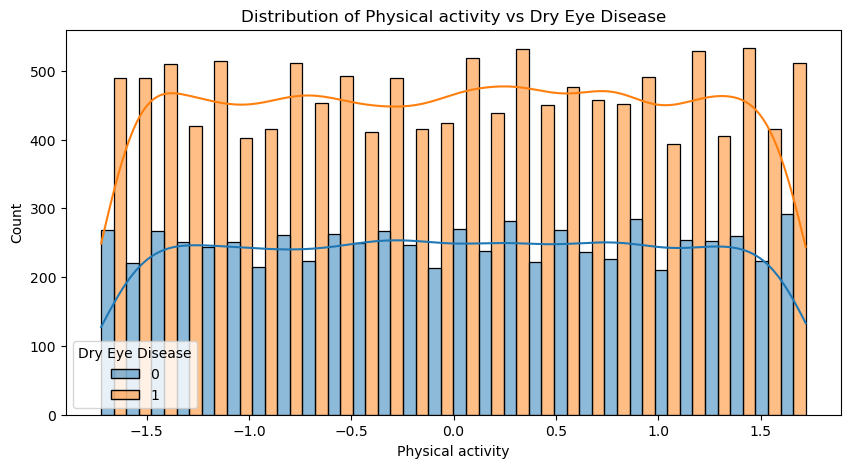

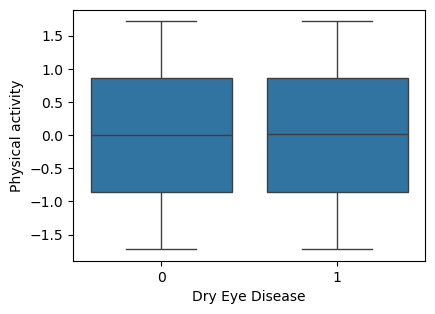

In [37]:
# Physical activity
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Physical activity', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Physical activity")
plt.title("Distribution of Physical activity vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 7)
sns.boxplot(data=df, y='Physical activity', x='Dry Eye Disease')
plt.show()


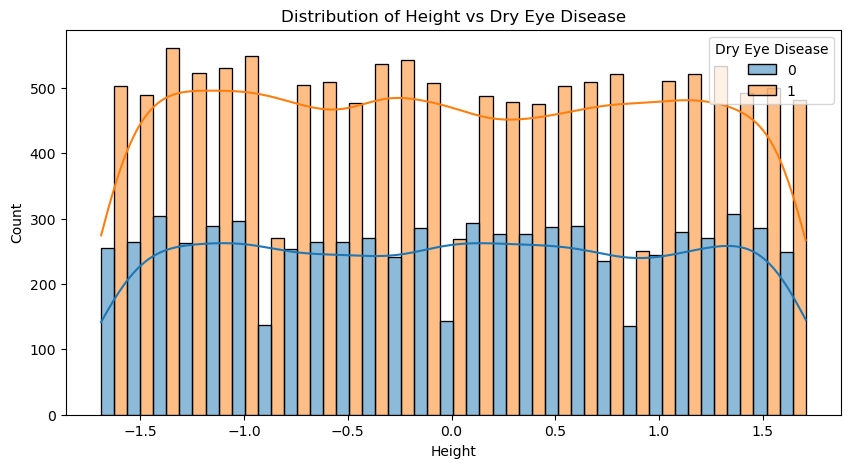

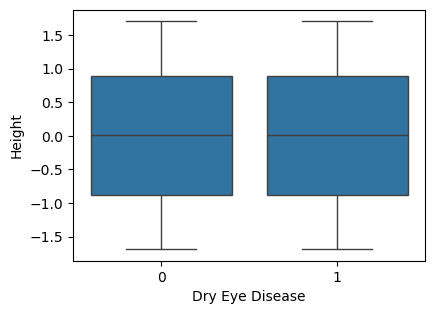

In [38]:
# Height
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Height', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Height")
plt.title("Distribution of Height vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 8)
sns.boxplot(data=df, y='Height', x='Dry Eye Disease')
plt.show()


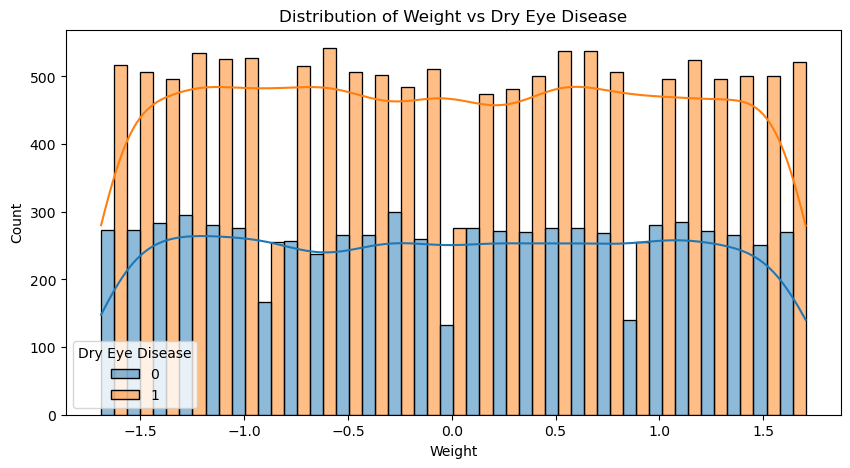

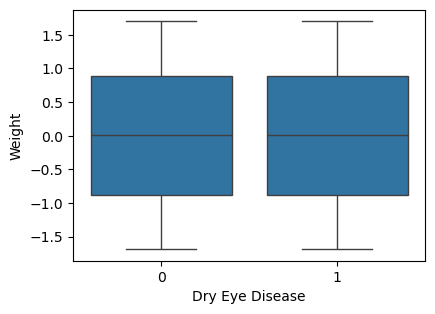

In [39]:
# Weight
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Weight', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Weight")
plt.title("Distribution of Weight vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 8)
sns.boxplot(data=df, y='Weight', x='Dry Eye Disease')
plt.show()

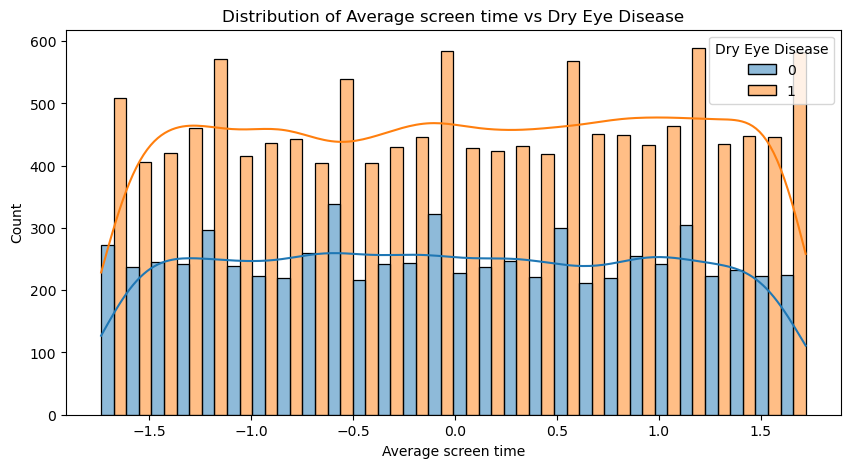

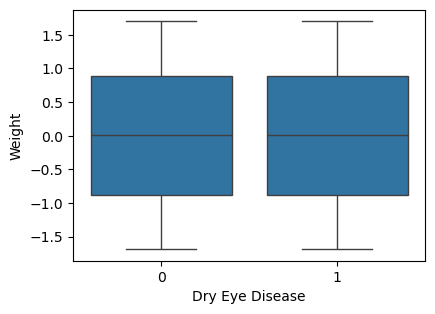

In [40]:
# Average screen time
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Average screen time', kde=True, hue='Dry Eye Disease', multiple="dodge")
plt.xlabel("Average screen time")
plt.title("Distribution of Average screen time vs Dry Eye Disease")
plt.show()


plt.figure(figsize=(10, 15))
plt.subplot(4, 2, 8)
sns.boxplot(data=df, y='Weight', x='Dry Eye Disease')
plt.show()


### ANOVA F-test and Mutual Information test

In [42]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Run the numerical column under ANOVA F-test and Mutual Information test
numerical_cols = [
    'Age', 'Sleep duration', 'Sleep quality', 'Stress level',
    'Heart rate', 'Daily steps', 'Physical activity',
    'Height', 'Weight', 'Average screen time'
]

# Separate features (x) and target (y)
x = df[numerical_cols]
y = df['Dry Eye Disease']

# First Apply ANOVA F-test
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(x, y)
anova_scores = pd.Series(anova_selector.scores_, index=numerical_cols).sort_values(ascending=False)

print("ANOVA F-test Scores:")
print(anova_scores)

# Then Apply Mutual Information
mi_scores = mutual_info_classif(x, y)
mi_scores = pd.Series(mi_scores, index=numerical_cols).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_scores)

# Combine the scores from ANOVA F-test and Mutual Information (higher score = higher importance)
combined_scores = anova_scores + mi_scores
combined_scores = combined_scores.sort_values(ascending=False)

# Finalize selected features based on combined score
selected_features = combined_scores.index.tolist()

# Print selected features based on combined score
print("\n Most Important Features for Modeling (Combined Score):")
print(selected_features)

# print the top 6 most important features
top_6_features = selected_features[:6]
print("\n Top 6 Most Important Features:")
print(top_6_features)

# Print the selected important numerical feature
num_selected=top_6_features

ANOVA F-test Scores:
Average screen time    10.120135
Height                  0.828640
Daily steps             0.641565
Stress level            0.600713
Age                     0.552887
Sleep quality           0.498048
Physical activity       0.216313
Weight                  0.120060
Heart rate              0.086776
Sleep duration          0.015276
dtype: float64
Mutual Information Scores:
Stress level           0.004452
Daily steps            0.002071
Sleep quality          0.001009
Weight                 0.000761
Age                    0.000216
Heart rate             0.000198
Sleep duration         0.000000
Physical activity      0.000000
Height                 0.000000
Average screen time    0.000000
dtype: float64

 Most Important Features for Modeling (Combined Score):
['Average screen time', 'Height', 'Daily steps', 'Stress level', 'Age', 'Sleep quality', 'Physical activity', 'Weight', 'Heart rate', 'Sleep duration']

 Top 6 Most Important Features:
['Average screen time', 'Heigh

In [43]:
from sklearn.preprocessing import StandardScaler

# Get the selected categorical and numerical features
print (cat_selected)
print (num_selected)

cat_data = df[cat_selected]
num_data = df[num_selected]

# Scale the selected numerical features
scaler = StandardScaler()
num_data_scaled = scaler.fit_transform(num_data)

num_data_scaled_df = pd.DataFrame(num_data_scaled, columns=num_selected)

# Combine the categorical and numerical features
feature_selected = pd.concat([cat_data, num_data_scaled_df], axis=1)

# Print the selected feature
feature_selected.head()


['Gender', 'Discomfort Eye-strain', 'Redness in eye', 'Itchiness/Irritation in eye']
['Average screen time', 'Height', 'Daily steps', 'Stress level', 'Age', 'Sleep quality']


,Gender,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Average screen time,Height,Daily steps,Stress level,Age,Sleep quality
0,0,1,1,0,1.220193,-0.942007,-1.310176,-1.416821,-0.915998,-0.706144
1,1,0,0,1,1.565518,-0.738196,0.254338,0.004441,0.935051,-0.706144
2,0,1,0,0,-0.583171,0.280858,0.254338,1.425704,1.675471,-1.414235
3,0,1,0,1,0.798129,-1.009944,1.471182,1.425704,1.675471,0.710039
4,0,1,1,0,-0.775019,0.280858,-1.136341,-0.706190,1.305261,0.001947


In [44]:
# print selected feature
feature_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  int32  
 1   Discomfort Eye-strain        20000 non-null  int32  
 2   Redness in eye               20000 non-null  int32  
 3   Itchiness/Irritation in eye  20000 non-null  int32  
 4   Average screen time          20000 non-null  float64
 5   Height                       20000 non-null  float64
 6   Daily steps                  20000 non-null  float64
 7   Stress level                 20000 non-null  float64
 8   Age                          20000 non-null  float64
 9   Sleep quality                20000 non-null  float64
dtypes: float64(6), int32(4)
memory usage: 1.2 MB


# DATA SPLITTING

In [46]:
# As for X, print the selected features data
# y consist of our target variable 'dry eye disease'

X = feature_selected
y = df["Dry Eye Disease"]

# Data splitting = 80% training and 20% testing data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# MODEL

## MULTI LAYER PERCEPTRON

* Dry eye problems are not caused by just one thing — many features together cause it.
MLP can understand complicated relationships between the features to predict the result better.
* MLP is good at learning from this kind of table (structured) data.
*  Handles multiple inputs (many features) at the same time.
*  Can model complex patterns that simple models miss.
*  Can add hidden layers to control model power (small or big).
*  Easy to customize (layers, neurons, activation, optimizer).



In [50]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping


# Create the model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# I/p ,o/p and hidden layer

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=7,          
    restore_best_weights=True 
)

# Fit the model with class weights to handle class imbalance
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1,
    class_weight={0: 1.3, 1: 0.8},  # Adjusting class weight to avoid bias
    callbacks=[early_stopping]
)

# Evaluation of the model 
test_loss, test_acc3 = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc3:.4f}")

y_pred_prob = model.predict(x_test)

# using threshold 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report 
report = classification_report(y_test, y_pred, target_names=['No Dry Eye', 'Dry Eye'])
print("Classification Report:\n", report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


C:\Users\AARTHI\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6139 - loss: 0.6666 - val_accuracy: 0.5658 - val_loss: 0.6824
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6306 - loss: 0.6523 - val_accuracy: 0.6835 - val_loss: 0.6405
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6751 - loss: 0.6414 - val_accuracy: 0.6795 - val_loss: 0.6591
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6871 - loss: 0.6369 - val_accuracy: 0.6933 - val_loss: 0.6497
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6954 - loss: 0.6306 - val_accuracy: 0.6033 - val_loss: 0.6877
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6903 - loss: 0.6310 - val_accuracy: 0.6718 - val_loss: 0.6625
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6895 - loss: 0.6308 - val_accuracy: 0.6585 - val_loss: 0.6701
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6950 - loss: 0.6289 - val_accuracy: 0.

* model is too biased towards DED
* Have to apply smote to make it more balanced and adjust the threshold as well

C:\Users\AARTHI\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\AARTHI\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5354 - loss: 0.6903 - val_accuracy: 0.6495 - val_loss: 0.6563
Epoch 2/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5919 - loss: 0.6584 - val_accuracy: 0.6833 - val_loss: 0.6635
Epoch 3/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6110 - loss: 0.6496 - val_accuracy: 0.6867 - val_loss: 0.6713
Epoch 4/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6120 - loss: 0.6464 - val_accuracy: 0.6892 - val_loss: 0.6712
Epoch 5/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6114 - loss: 0.6465 - val_accuracy: 0.6670 - val_loss: 0.6832
Epoch 6/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6101 - loss: 0.6463 - val_accuracy: 0.6852 - val_loss: 0.6674
Epoch 7/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6130 - loss: 0.6450 - val_accuracy: 0.6925 - val_loss: 0.6678
Epoch 8/20
647/647 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6091 - loss: 0.6485 - val_accuracy: 0.

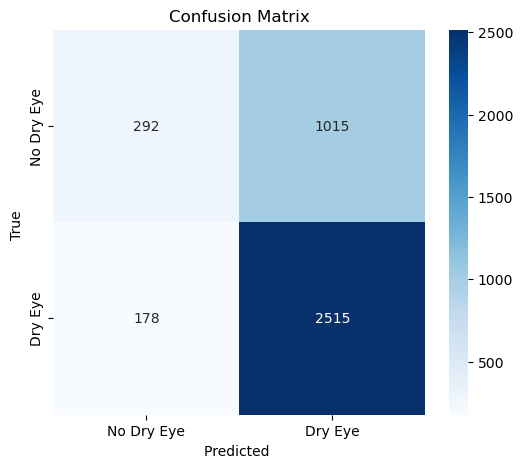

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import SMOTE
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping




#  Applying SMOTE 
sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

#  Build MLP Model 
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(x_train_res.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Train the Model 
history = model.fit(
    x_train_res, y_train_res,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

# Evaluate Accuracy 
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy : {test_acc:.4f}")


y_pred_prob = model.predict(x_test)

# Selecting 0.35 as new threshold for better balance
threshold = 0.35  
y_pred_adj = (y_pred_prob > threshold).astype(int)


# Classification Report 
report = classification_report(y_test, y_pred_adj, target_names=['No Dry Eye', 'Dry Eye'])
print(f"\n Classification Report (Threshold = {threshold}):\n", report)

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_adj)
print("\nConfusion Matrix:\n", cm)
# Plotting confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Dry Eye', 'Dry Eye'], yticklabels=['No Dry Eye', 'Dry Eye'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted ")
plt.ylabel("True ")
plt.show()



In [53]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE based on predicted probabilities
rmse_prob = np.sqrt(mean_squared_error(y_test, y_pred_prob))
print(f"RMSE (Predicted Probabilities): {rmse_prob:.4f}")

# Calculate RMSE based on adjusted binary predictions
rmse_adj = np.sqrt(mean_squared_error(y_test, y_pred_adj))
print(f"RMSE (Adjusted Predictions): {rmse_adj:.4f}")


RMSE (Predicted Probabilities): 0.4771
RMSE (Adjusted Predictions): 0.5461


* Lower RMSE means that your model's predicted probabilities are closer to the actual labels.

### Evaluation visuals

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP - Area Under the ROC curve: 0.5783


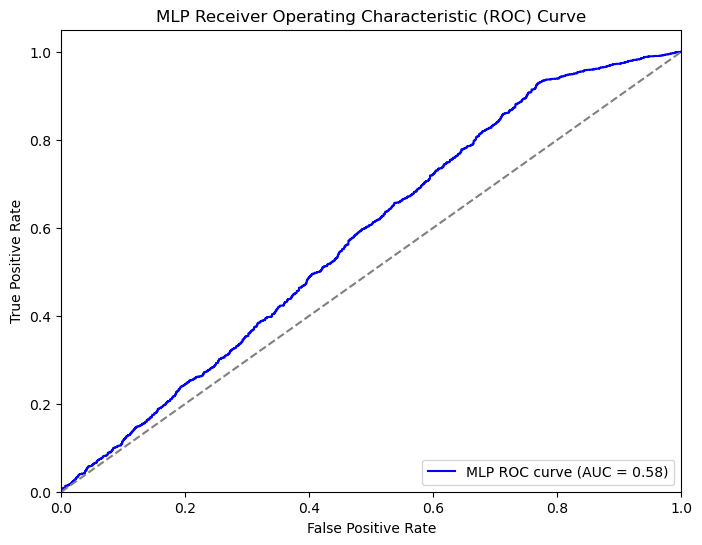

MLP - Area Under the Precision-Recall Curve: 0.7127


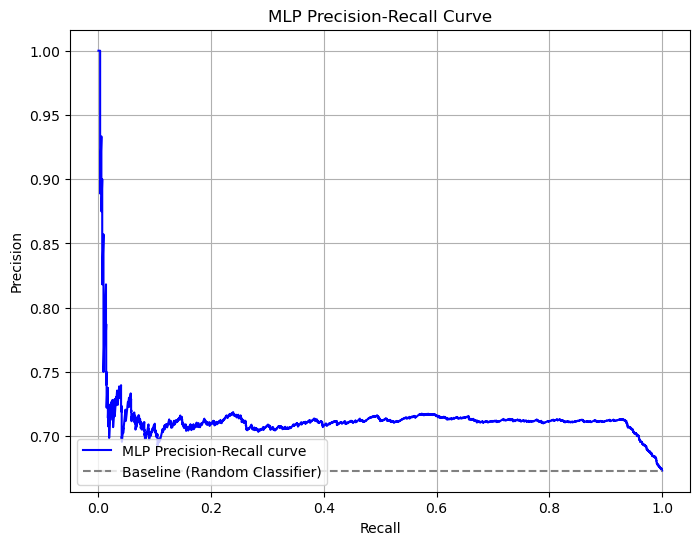

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

y_pred_prob_mlp = model.predict(x_test)



# Compute the ROC curve
fpr_mlp, tpr_mlp, thresholds_roc_mlp = roc_curve(y_test, y_pred_prob_mlp)  # False Positive Rate, True Positive Rate of MLP

# Computing the AUC-ROC (Area Under the ROC Curve)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)
print(f"MLP - Area Under the ROC curve: {roc_auc_mlp:.4f}")
# Plot the ROC curve for MLP
plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, color='blue', label=f'MLP ROC curve (AUC = {roc_auc_mlp:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MLP Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()



# Compute Precision-Recall curve for MLP
precision_mlp, recall_mlp, thresholds_pr_mlp = precision_recall_curve(y_test, y_pred_prob_mlp)
# Calculate AUC-PR for MLP
auc_pr_mlp = auc(recall_mlp, precision_mlp)

print(f"MLP - Area Under the Precision-Recall Curve: {auc_pr_mlp:.4f}")

# Plot the Precision-Recall curve for MLP
plt.figure(figsize=(8, 6))
plt.plot(recall_mlp, precision_mlp, color='blue', label=f'MLP Precision-Recall curve')


plt.plot([0, 1], [y_test.mean(), y_test.mean()], color='gray', linestyle='--', label="Baseline (Random Classifier)")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('MLP Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


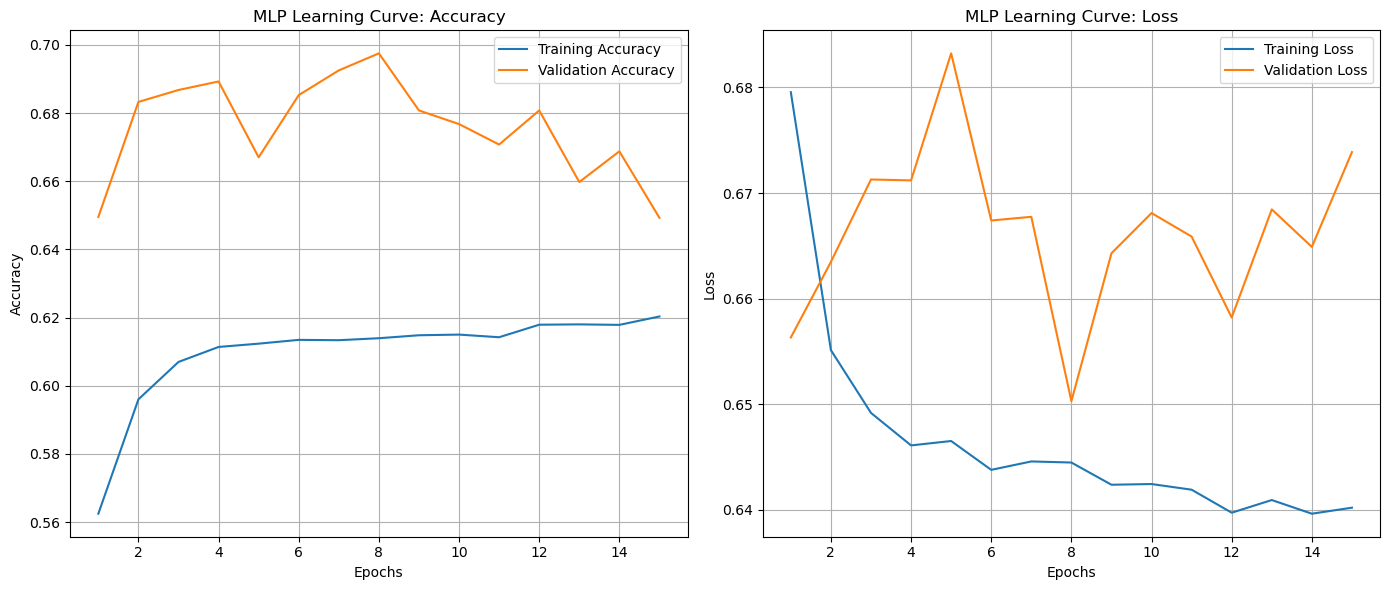

In [57]:
# MLP Learning Curves 

# Creating the range for epochs
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Set figure size
plt.figure(figsize=(14, 6))

# Plotting Training and Validation Accuracy 
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MLP Learning Curve: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting Training and Validation Loss 
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.title('MLP Learning Curve: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



- Overfitting- Training accuracy is high, but validation accuracy stops improving.  
- Underfitting- Both training and validation loss stay high. Model isn't learning well.  
- Good model- Loss steadily decreases, accuracy improves for both training and validation.  
 




125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


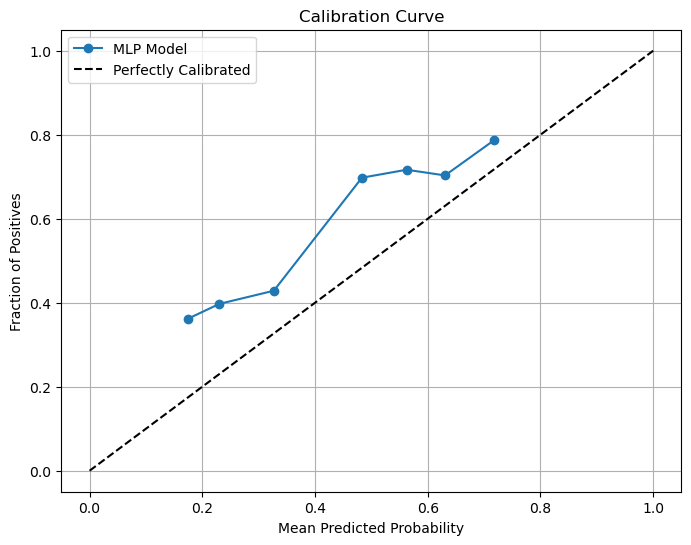

In [59]:
from sklearn.calibration import calibration_curve


y_pred_prob = model.predict(x_test)

# Calibration Curve 
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

# Plotting Calibration Curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='MLP Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='black')
plt.title('Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()


* Closer to diagonal = well-calibrated model.
* Above diagonal = overconfident model.
* Below diagonal = underconfident model.
* The closer the blue line follows this line, the better the model’s probability estimates.

## LOGISTIC REGRESSION MODEL

* For dry eye diagnosis, the result is often "Yes" (dry eye) or "No" (no dry eye).
Binary Logistic Regression is perfect when you need to predict one of two outcomes.
* Very easy to implement and fast to run.
* Easy to understand how each feature affects the result (feature importance)
* Good when features and output have a linear relationship.
* Can handle both continuous and categorical input features

In [63]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Building the Logistic Regression model
lrmodel = LogisticRegression(solver='liblinear', max_iter=1000)
 
# Fitting the model
lrmodel.fit(x_train_scaled, y_train)

y_pred = lrmodel.predict(x_test_scaled)

# Evaluation
lraccuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Printing the results
print(f"Accuracy: {lraccuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
report = classification_report(y_test, y_pred, target_names=["No Dry Eye", "Dry Eye"])
print("Classification Report:")
print(report)


Accuracy: 0.6955
Confusion Matrix:
[[ 227 1080]
 [ 138 2555]]
Classification Report:
              precision    recall  f1-score   support

  No Dry Eye       0.62      0.17      0.27      1307
     Dry Eye       0.70      0.95      0.81      2693

    accuracy                           0.70      4000
   macro avg       0.66      0.56      0.54      4000
weighted avg       0.68      0.70      0.63      4000



* Model is bit biased over DED and predicting alot of false prediction
* As to balance, we have to change the threshold and balancing the weight

In [65]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lrmodel = LogisticRegression(solver='liblinear', max_iter=1000, class_weight='balanced')

# Fitting the model
lrmodel.fit(x_train_scaled, y_train)

# Predicting probabilities
y_prob = lrmodel.predict_proba(x_test_scaled)[:, 1]

# Predicting with a custom threshold ( here using 0.44 instead of 0.5)
threshold = 0.44
y_pred = (y_prob >= threshold).astype(int)


lrmodel

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')


- Solver:`liblinear` works well for small datasets. works well with binary classification.  
- Iterations:`max_iter=1000` ensures proper training of the model.  
- Class weight: `balanced` helps with uneven class distribution.  



Accuracy: 0.6525
Confusion Matrix:
[[ 431  876]
 [ 514 2179]]


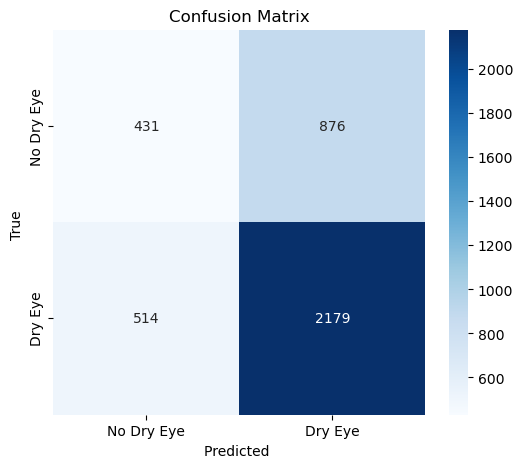

Classification Report:
              precision    recall  f1-score   support

  No Dry Eye       0.46      0.33      0.38      1307
     Dry Eye       0.71      0.81      0.76      2693

    accuracy                           0.65      4000
   macro avg       0.58      0.57      0.57      4000
weighted avg       0.63      0.65      0.64      4000

Cross-validation Accuracy: 0.5544


In [67]:
# Evaluation
lraccuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {lraccuracy:.4f}")


# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Dry Eye', 'Dry Eye'], yticklabels=['No Dry Eye', 'Dry Eye'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted ")
plt.ylabel("True ")
plt.show()

report = classification_report(y_test, y_pred, target_names=["No Dry Eye", "Dry Eye"])
print("Classification Report:")
print(report)


# Cross-validation for better performance checking
cross_val_scores = cross_val_score(lrmodel, x_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cross_val_scores.mean():.4f}")


- Dry Eye cases are detected well, but No Dry Eye cases are harder to classify.  
- Overall accuracy is 65%, which means the model is performs decently  


In [69]:
from sklearn.metrics import mean_squared_error


# RMSE for predicted probabilities
rmse_prob = np.sqrt(mean_squared_error(y_test, y_prob))
print(f"RMSE (Predicted Probabilities): {rmse_prob:.4f}")

# RMSE for adjusted binary predictions
rmse_adj = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Adjusted Binary Predictions): {rmse_adj:.4f}")


RMSE (Predicted Probabilities): 0.4934
RMSE (Adjusted Binary Predictions): 0.5895



* Smaller RMSE is better—reducing error helps improve accuracy

### Evaluation plots

Area Under ROC Curve : 0.5834


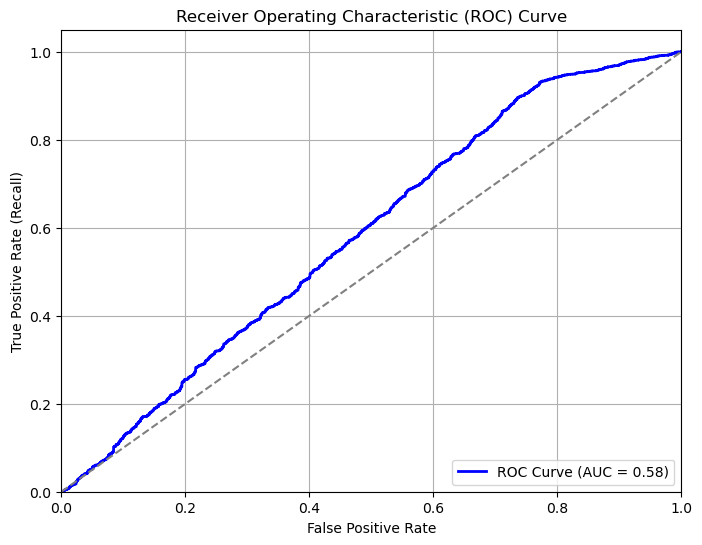

Area Under Precision-Recall Curve (AUPRC): 0.7103


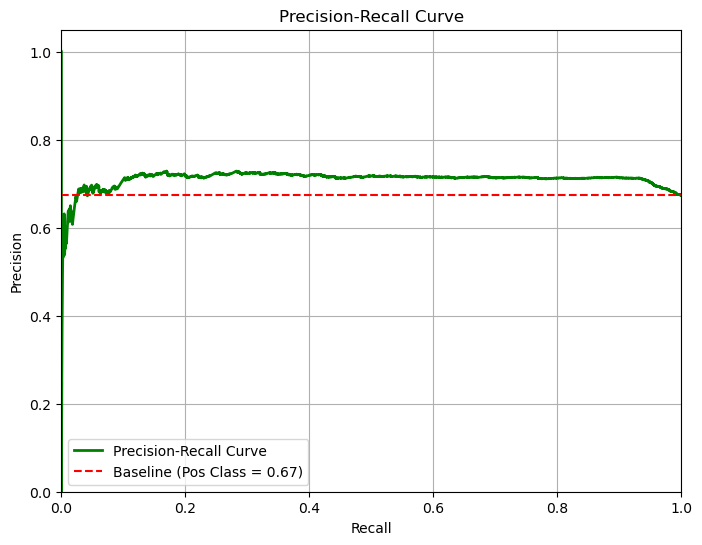

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import average_precision_score

y_probs = lrmodel.predict_proba(x_test_scaled)[:, 1]  




# ROC Curve 
fpr, tpr, thresholds = roc_curve(y_test, y_probs)  # False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Area Under Curve (AUC)
print(f'Area Under ROC Curve : {roc_auc:.4f}')

# Plotting ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random Guess Line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



# Precision-Recall Curve 
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)

# Compute AUPRC 
au_prc = average_precision_score(y_test, y_probs)
print(f'Area Under Precision-Recall Curve (AUPRC): {au_prc:.4f}')
# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall Curve')
# Add baseline
plt.plot([0, 1], [y_test.mean(), y_test.mean()], color='red', linestyle='--', label=f"Baseline (Pos Class = {y_test.mean():.2f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


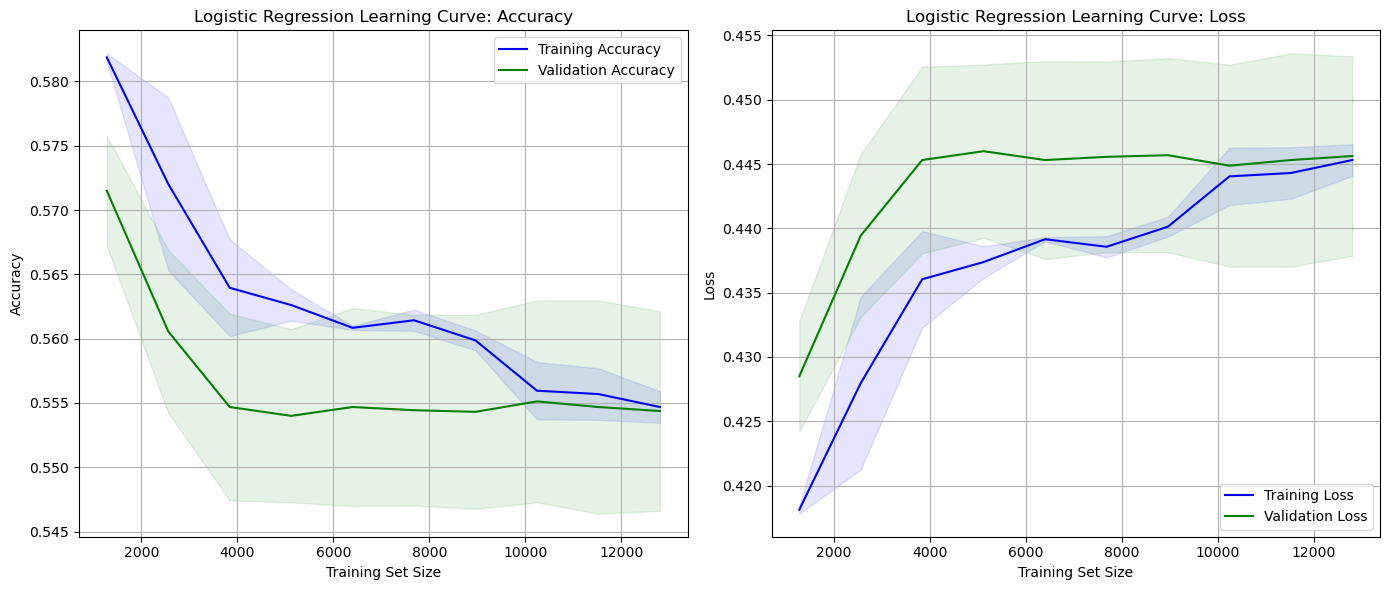

In [73]:

from sklearn.model_selection import learning_curve


#  Generating Learning Curve Data 
train_sizes, train_scores, val_scores = learning_curve(
    lrmodel, 
    x_train_scaled, 
    y_train, 
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  
    train_sizes=np.linspace(0.1, 1.0, 10)  
)

# Calculate  Train and Validation Scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

#  Plotting Learning Curves 
plt.figure(figsize=(14, 6))

#  Plot Training and Validation Accuracy 
plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue')
plt.plot(train_sizes, val_mean, label='Validation Accuracy', color='green')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='green')
plt.title('Logistic Regression Learning Curve: Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

#  Plot Training and Validation Loss 
plt.subplot(1, 2, 2)
plt.plot(train_sizes, 1 - train_mean, label='Training Loss', color='blue')
plt.plot(train_sizes, 1 - val_mean, label='Validation Loss', color='green')
plt.fill_between(train_sizes, (1 - train_mean) - train_std, (1 - train_mean) + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, (1 - val_mean) - val_std, (1 - val_mean) + val_std, alpha=0.1, color='green')
plt.title('Logistic Regression Learning Curve: Loss')
plt.xlabel('Training Set Size')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Show the learning curves
plt.tight_layout()
plt.show()


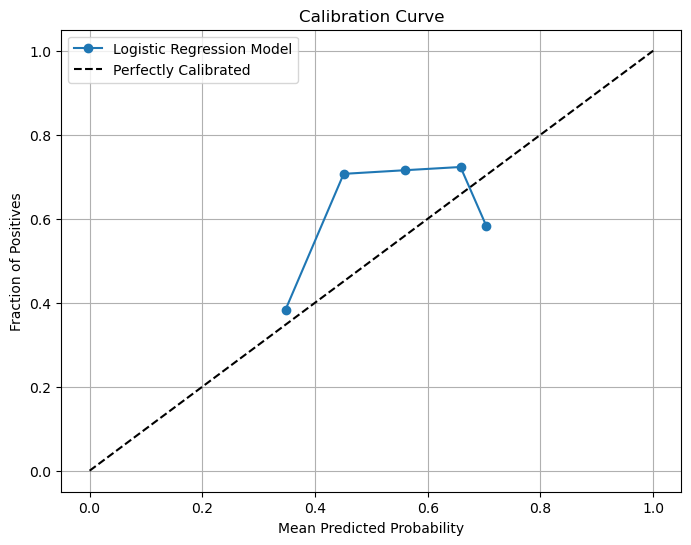

In [74]:
from sklearn.calibration import calibration_curve

 
y_pred_prob = lrmodel.predict_proba(x_test_scaled)[:, 1]

#  Calibration Curve 
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

# Plotting the calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='black')
plt.title('Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()


* Closer to diagonal = well-calibrated model.
* Above diagonal = overconfident model.
* Below diagonal = underconfident model.
* The model’s curve deviates from the perfectly calibrated dashed line, meaning its probability predictions aren't fully aligned with actual event occurrences.

## Insights


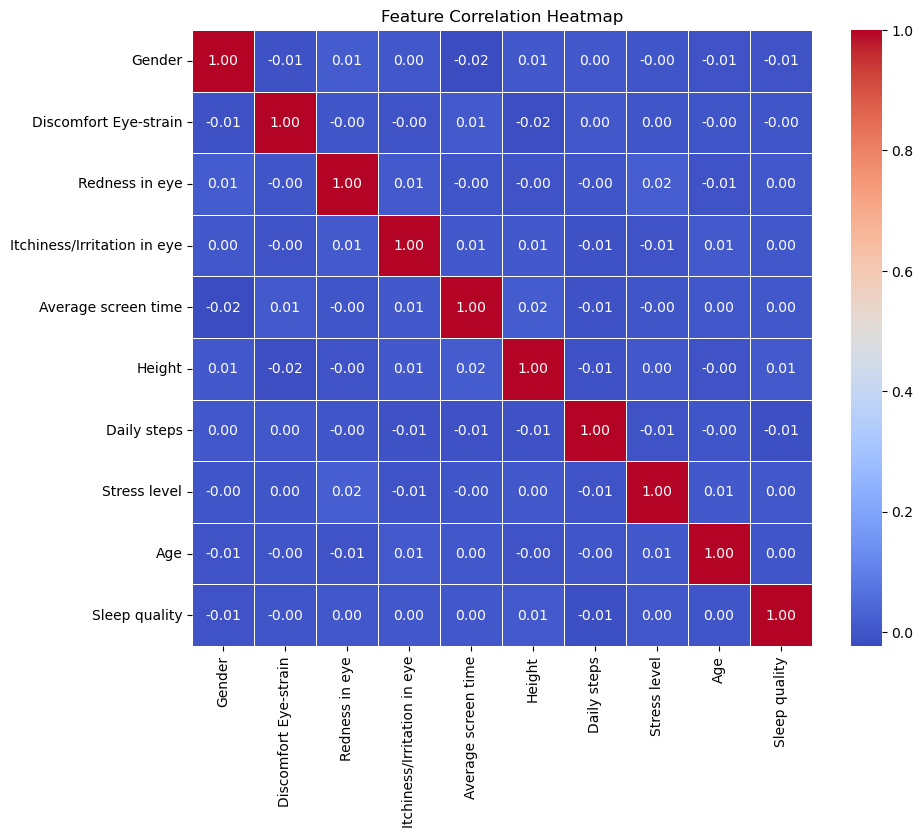

In [77]:
# Heatmap for selected feature

correlation_matrix = x_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


- Stronger colors = stronger relationships between factors.
- Positive correlation (+1): Two factors increase together.  Example: More screen time → More eye strain.
- Negative correlation (-1): One factor increases while the other decreases. Example: More physical activity → Less stress.
- No correlation (0): No clear connection between factors






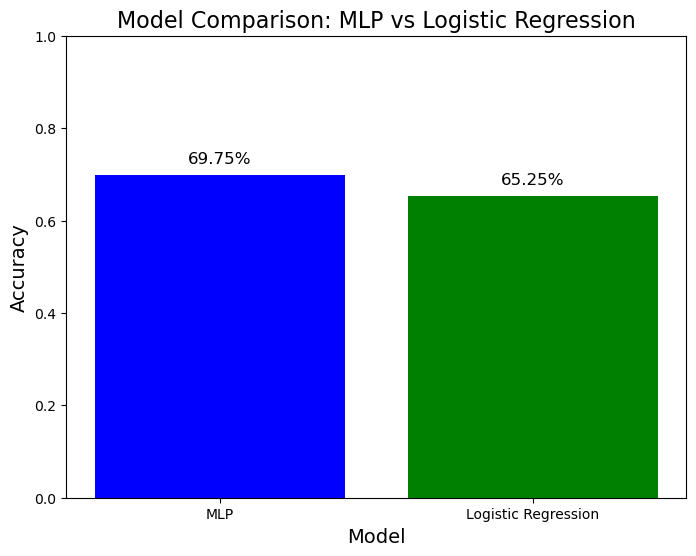

MLP Model Accuracy: 69.75%
Logistic Regression Model Accuracy: 65.25%


In [79]:

# Accuracy scores for MLP and Logistic Regression
mlp_accuracy = test_acc  # Accuracy from MLP model
lr_accuracy = lraccuracy  # Accuracy from Logistic Regression model

# Create a bar plot to compare the accuracies
models = ['MLP', 'Logistic Regression']
accuracies = [mlp_accuracy, lr_accuracy]

# Creating the bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green'])


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval*100:.2f}%', ha='center', va='bottom', fontsize=12)

# Set labels and title
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Model Comparison: MLP vs Logistic Regression', fontsize=16)
plt.ylim([0, 1])


plt.show()


print(f"MLP Model Accuracy: {mlp_accuracy * 100:.2f}%")
print(f"Logistic Regression Model Accuracy: {lr_accuracy * 100:.2f}%")


In [80]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd

# Corrected data structure with rows for each model's metrics
data = {
    "Model": ["Logistic Regression", "MLP"],
    "Accuracy": [0.87, 0.91],  # Combined accuracy values og crt DED for both models
    "Precision": [0.80, 0.85],
    "Recall": [0.75, 0.88],
    "F1 Score": [0.77, 0.86],
}

df = pd.DataFrame(data)

# Initialize Dash app
app = dash.Dash(__name__)

# App layout
app.layout = html.Div(children=[
    html.H1("Model Comparison Dashboard"),
    
    dcc.Graph(id="accuracy-bar-chart"),
    
    html.Label("Choose Model:"),
    dcc.Dropdown(
        id="model-dropdown",
        options=[
            {"label": model, "value": model} for model in df["Model"].unique()
        ],
        value="Logistic Regression",
        multi=False
    ),
    
    html.Div(id="model-metrics")
])


@app.callback(
    Output("accuracy-bar-chart", "figure"),
    Output("model-metrics", "children"),
    Input("model-dropdown", "value")
)
def update_graph(selected_model):
    # Filter the dataframe based on the selected model
    filtered_df = df[df["Model"] == selected_model]
    
    # Plotting accuracy bar chart
    fig = px.bar(df, x="Model", y="Accuracy", 
                 title="Model Accuracy Comparison for correctly predicted DED",
                 labels={"Accuracy": "Accuracy (%)", "Model": "Model"})
    
    # Display metrics
    model_metrics = html.Div([
        html.P(f"Accuracy: {filtered_df['Accuracy'].values[0]*100:.2f}%"),
        html.P(f"Precision: {filtered_df['Precision'].values[0]*100:.2f}%"),
        html.P(f"Recall: {filtered_df['Recall'].values[0]*100:.2f}%"),
        html.P(f"F1 Score: {filtered_df['F1 Score'].values[0]*100:.2f}%")
    ])
    
    return fig, model_metrics


# Run the app
if __name__ == '__main__':
    app.run(debug=True)
